# PyTorch workflow

This notebook cover a standard PyTorch workflow shown below in the image.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png" alt="PyTorch Workflow"  width="900" height="300">

For now, we'll use this workflow to predict a simple straight line but the workflow steps can be repeated and changed depending on the problem you're working on.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

#### 1. Data (preparing and loading)

In [2]:
# create *known* parameters
weights = 0.7
bias = 0.3

# create data
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step)
y = weights*X + bias
print(len(y))

50


In [3]:
X[:10] , y[:10]

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
         0.1800]),
 tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560, 0.3700, 0.3840, 0.3980, 0.4120,
         0.4260]))

In [4]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split

X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False) 

In [5]:
len(X_train) , len(X_test) , len(y_train) , len(y_test)

(40, 10, 40, 10)

In [ ]:
# Create function to visualise the data
def plot_predictions(train_data = X_train,
                     train_labels =y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
    plt.figure(figsize=(8,7))

    # train data
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # test data
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")


    if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14});                  

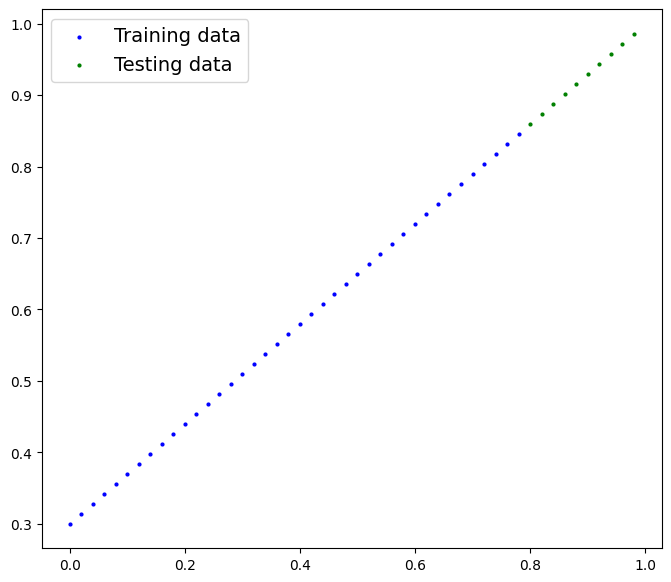

In [7]:
plot_predictions();

#### 2. Build a Model

In [ ]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                   dtype = torch.float,
                                   requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1,
                                             dtype = torch.float,
                                             requires_grad=True))

    # def forward method for computation
    def forward(self,x:torch.Tensor)->torch.Tensor:
            return self.weights * x + self.bias
            

In [9]:
# check the contents of the model
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
# list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [11]:
# make predictions 
with torch.inference_mode():
    y_preds = model_0(X_test)

In [ ]:
y_preds , y_test

(tensor([0.3982, 0.4049, 0.4116, 0.4184, 0.4251, 0.4318, 0.4386, 0.4453, 0.4520,
         0.4588]),
 tensor([0.8600, 0.8740, 0.8880, 0.9020, 0.9160, 0.9300, 0.9440, 0.9580, 0.9720,
         0.9860]))

In [13]:
y_test-y_preds

tensor([0.4618, 0.4691, 0.4764, 0.4836, 0.4909, 0.4982, 0.5054, 0.5127, 0.5200,
        0.5272])

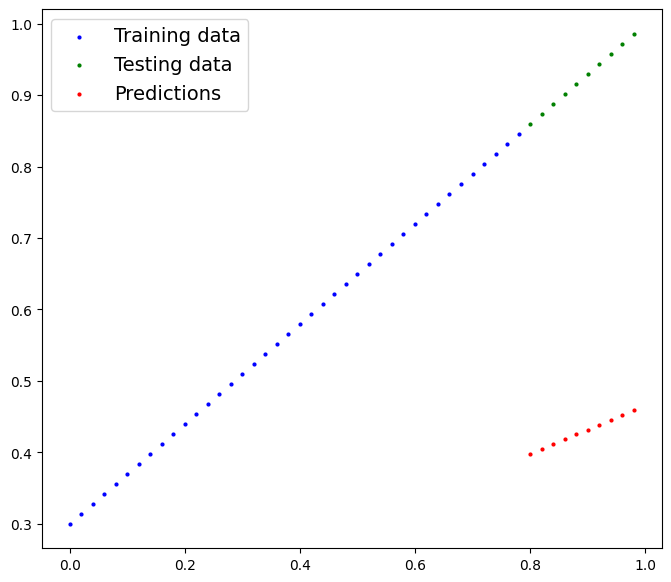

In [14]:
# visualise it
plot_predictions(predictions=y_preds);

We have to close the gap between `green` and `red` i.e actual and predications.

#### 3. Train model

In [15]:
# setup loss function and optimizer
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01)

In [16]:
# training loop
epochs = 50

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    model_0.train()

    # forward pass (model predictions)
    y_pred = model_0(X_train)

    # calculate loss
    loss = loss_fn(y_pred , y_train)

    # zero grad optimizer (Reset gradients before the new batch processing)
    optimizer.zero_grad()

    # loss backward (Compute gradients via backpropagation)
    loss.backward()

    # progress optimizer (Update model parameters)
    optimizer.step()


    ### testing

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)

        # calculate the loss on test data
        test_loss = loss_fn(test_pred ,  y_test)

        if epoch%10==0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())

            # print
            print(f"Epoch : {epoch}  || Train Loss {loss} || Test Loss {test_loss}")

Epoch : 0  || Train Loss 0.31288138031959534 || Test Loss 0.48106518387794495
Epoch : 10  || Train Loss 0.1976713240146637 || Test Loss 0.3463551998138428
Epoch : 20  || Train Loss 0.08908725529909134 || Test Loss 0.21729660034179688
Epoch : 30  || Train Loss 0.053148526698350906 || Test Loss 0.14464017748832703
Epoch : 40  || Train Loss 0.04543796554207802 || Test Loss 0.11360953003168106


In [17]:
with torch.inference_mode():
    new_pred = model_0(X_test)

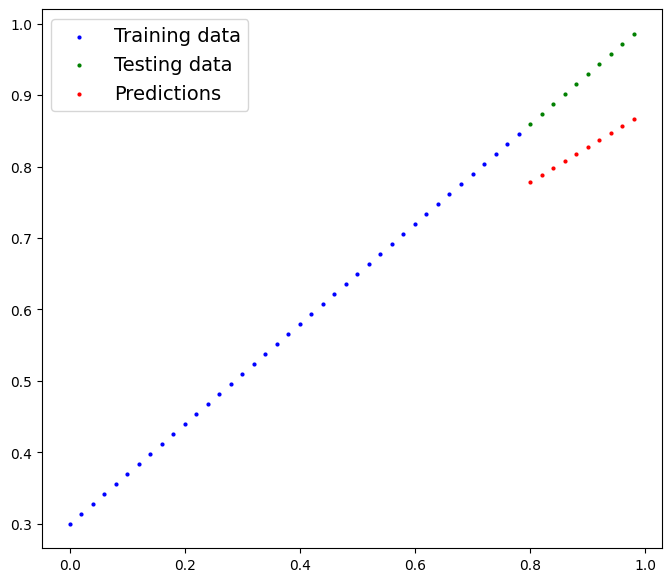

In [18]:
plot_predictions(predictions=new_pred)

In [19]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weights}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.4920]), 'bias': tensor([0.3848])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


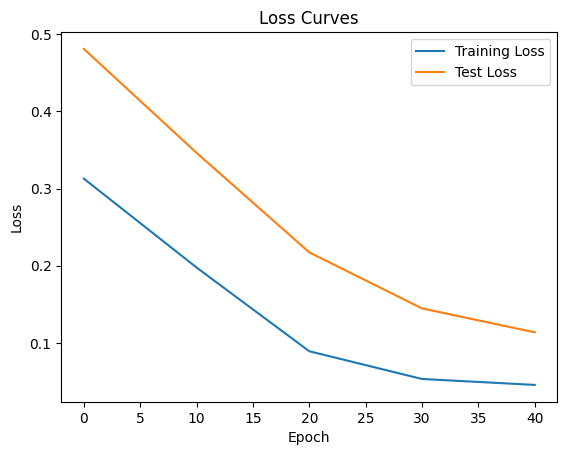

In [29]:
# plotting loss curves
plt.plot(epoch_count,train_loss_values,label = 'Training Loss')
plt.plot(epoch_count, test_loss_values, label = "Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend();